# Publication figures from completed carry-on benchmark tables

Run this notebook from the repository root, `results/`, or `results/tables/`. It reads the three completed comparison CSVs and produces paper-style PDF + PNG figures.

**Design clarification.** Each comparison uses a one-product replacement design. For a given product, four products remain in the baseline condition and only the target product is replaced by the comparison condition. This is repeated across the five products.

| Comparison | Exact setup | Interpretation |
|---|---|---|
| Current over old | All-old baseline vs one-product 2026-current replacement | Observed 2026 current-page movement |
| GEO over old | All-old baseline vs one-product GEO-style rewrite replacement | Hypothetical GEO-rewrite direction |
| GEO over current | All-current baseline vs one-product GEO-style rewrite replacement | Direct GEO-vs-current contrast |

The figures do not claim firm intent. They summarize answer-behavior movement under the benchmark setup.


In [10]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from IPython.display import display, Image

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 350,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
    "savefig.transparent": False,
    "font.family": "DejaVu Sans",
    "font.size": 7.5,
    "axes.titlesize": 8.0,
    "axes.labelsize": 7.5,
    "xtick.labelsize": 7.0,
    "ytick.labelsize": 7.0,
    "legend.fontsize": 7.0,
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def mm_to_inch(w, h):
    return (w / 25.4, h / 25.4)

PRODUCT_ORDER = ["Monos", "BÉIS", "Travelpro", "INUSA", "Delsey"]
PRODUCT_ALIASES = {
    "monos": "Monos",
    "beis": "BÉIS",
    "béis": "BÉIS",
    "travel": "Travelpro",
    "tarvel": "Travelpro",
    "travelpro": "Travelpro",
    "inusa": "INUSA",
    "delsey": "Delsey",
}

FIGSIZE_HEATMAP_FULL = mm_to_inch(170, 62)
FIGSIZE_SCATTER_SINGLE = mm_to_inch(85, 68)
FIGSIZE_SCATTER_FULL = mm_to_inch(170, 72)
FIGSIZE_SUPP_FULL = mm_to_inch(170, 90)

In [11]:
def find_tables_dir(start=None):
    start = Path.cwd() if start is None else Path(start)
    candidates = []
    for p in [start] + list(start.parents):
        candidates += [
            p,
            p / "results" / "tables",
            p / "code" / "data" / "results" / "tables",
            p / "data" / "results" / "tables",
        ]
    for base in [start, start.parent]:
        if base.exists():
            candidates += list(base.glob("**/results/tables"))
            candidates += list(base.glob("**/code/data/results/tables"))

    seen, unique = set(), []
    for c in candidates:
        try:
            c = c.resolve()
        except Exception:
            continue
        if c not in seen:
            seen.add(c)
            unique.append(c)

    for c in unique:
        if c.exists() and c.is_dir():
            if any(child.is_dir() and child.name.startswith(("01_", "02_", "03_")) for child in c.iterdir()):
                return c

    checked = "\n".join(str(c) for c in unique[:40])
    raise FileNotFoundError("Could not find results/tables. Checked:\n" + checked)

TABLES_DIR = find_tables_dir()
RESULTS_DIR = TABLES_DIR.parent
FIG_MAIN_DIR = RESULTS_DIR / "figures" / "main"
FIG_SUPP_DIR = RESULTS_DIR / "figures" / "supplementary"
FIG_TABLE_DIR = TABLES_DIR / "figure_outputs"
for d in [FIG_MAIN_DIR, FIG_SUPP_DIR, FIG_TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("TABLES_DIR:", TABLES_DIR)
print("FIG_MAIN_DIR:", FIG_MAIN_DIR)
print("FIG_SUPP_DIR:", FIG_SUPP_DIR)

TABLES_DIR: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\results\tables
FIG_MAIN_DIR: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\results\figures\main
FIG_SUPP_DIR: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\results\figures\supplementary


In [12]:
def find_csv(folder_prefix, file_name):
    matches = sorted(TABLES_DIR.glob(f"{folder_prefix}*/{file_name}"))
    if not matches:
        matches = [p for p in sorted(TABLES_DIR.glob(f"**/{file_name}")) if p.parent.name.startswith(folder_prefix)]
    if not matches:
        available = "\n".join(str(p.relative_to(TABLES_DIR)) for p in sorted(TABLES_DIR.glob("**/*.csv"))[:100])
        raise FileNotFoundError(f"Missing {file_name} under {folder_prefix}*. Available CSVs:\n{available}")
    return matches[0]

PATH_01 = find_csv("01_", "current_vs_baseline_delta_by_product.csv")
PATH_02 = find_csv("02_", "geo_vs_baseline_delta_by_product.csv")
PATH_03 = find_csv("03_", "geo_vs_current_delta_by_product.csv")

comp01 = pd.read_csv(PATH_01)
comp02 = pd.read_csv(PATH_02)
comp03 = pd.read_csv(PATH_03)

print("01:", PATH_01.relative_to(TABLES_DIR))
print("02:", PATH_02.relative_to(TABLES_DIR))
print("03:", PATH_03.relative_to(TABLES_DIR))
print("Shapes:", comp01.shape, comp02.shape, comp03.shape)

01: 01_2023_2024_original_vs_2026_current_baseline_based\current_vs_baseline_delta_by_product.csv
02: 02_2023_2024_original_vs_2023_2024_geo_rewrite_baseline_based\geo_vs_baseline_delta_by_product.csv
03: 03_2026_current_vs_2023_2024_geo_rewrite_baseline_current_chunked_based\geo_vs_current_delta_by_product.csv
Shapes: (5, 33) (5, 33) (5, 33)


In [13]:
def normalize_product(x):
    if pd.isna(x):
        return x
    s = str(x).strip()
    lower = s.lower()
    first = lower.replace("_", " ").replace("-", " ").split()[0]
    if first in PRODUCT_ALIASES:
        return PRODUCT_ALIASES[first]
    for alias, canonical in PRODUCT_ALIASES.items():
        if alias in lower:
            return canonical
    return s


def infer_product_col(df):
    for c in ["product", "Product", "product_label", "label", "brand", "Brand"]:
        if c in df.columns:
            return c
    best_col, best_score = None, -1
    for c in df.columns:
        vals = df[c].astype(str).str.lower().head(50)
        score = sum(any(alias in v for alias in PRODUCT_ALIASES) for v in vals)
        if score > best_score:
            best_col, best_score = c, score
    if best_score <= 0:
        raise ValueError(f"Could not infer product column: {list(df.columns)}")
    return best_col


def infer_advantage_col(df, keywords):
    for c in df.columns:
        lc = c.lower()
        if "advantage" in lc and all(k in lc for k in keywords):
            return c
    candidates = [c for c in df.columns if "advantage" in c.lower() and pd.api.types.is_numeric_dtype(df[c])]
    if len(candidates) == 1:
        return candidates[0]
    raise ValueError(f"Could not infer advantage column for {keywords}. Columns: {list(df.columns)}")


def product_advantage(df, keywords, out_col):
    pcol = infer_product_col(df)
    vcol = infer_advantage_col(df, keywords)
    out = df[[pcol, vcol]].copy()
    out.columns = ["product", out_col]
    out["product"] = out["product"].map(normalize_product)
    out[out_col] = pd.to_numeric(out[out_col], errors="coerce")
    return out.dropna().groupby("product", as_index=False)[out_col].mean()

summary = product_advantage(comp01, ["current"], "current_over_old")
summary = summary.merge(product_advantage(comp02, ["geo"], "geo_over_old"), on="product", how="outer")
summary = summary.merge(product_advantage(comp03, ["geo", "current"], "geo_over_current"), on="product", how="outer")
summary["order"] = summary["product"].map({p:i for i,p in enumerate(PRODUCT_ORDER)}).fillna(999)
summary = summary.sort_values(["order", "product"]).drop(columns="order").reset_index(drop=True)
summary["current_minus_geo_old_effect"] = summary["current_over_old"] - summary["geo_over_old"]
summary["same_direction_old_baseline"] = np.sign(summary["current_over_old"]) == np.sign(summary["geo_over_old"])
summary.to_csv(FIG_TABLE_DIR / "figure_product_level_summary.csv", index=False)
display(summary)

,product,current_over_old,geo_over_old,geo_over_current,current_minus_geo_old_effect,same_direction_old_baseline
0,Monos,0.212912,0.075915,-0.213358,0.136997,True
1,BÉIS,0.077565,0.007779,-0.000677,0.069785,True
2,Travelpro,0.064281,0.050848,0.021177,0.013432,True
3,INUSA,0.019176,0.010693,-0.038033,0.008483,True
4,Delsey,-0.079008,-0.109062,0.011036,0.030054,True


In [14]:
def save_pdf_png(fig, out_base, show=True):
    out_base = Path(out_base)
    out_base.parent.mkdir(parents=True, exist_ok=True)
    pdf_path = out_base.with_suffix(".pdf")
    png_path = out_base.with_suffix(".png")
    fig.savefig(pdf_path, bbox_inches="tight", facecolor="white", transparent=False)
    fig.savefig(png_path, bbox_inches="tight", facecolor="white", transparent=False, dpi=350)
    plt.close(fig)
    print("Saved:", pdf_path)
    print("Saved:", png_path)
    if show:
        display(Image(filename=str(png_path)))


def annotation_color(value, cmap, norm, threshold=0.55):
    r, g, b, _ = cmap(norm(value))
    luminance = 0.2126*r + 0.7152*g + 0.0722*b
    return "white" if luminance < threshold else "black"

## Main Figure 1 — Product-level one-product replacement effects

This is the primary result figure. Each cell is an advantage-score difference from a one-product replacement run. Positive values mean that the replacement condition produced stronger benchmark answer behavior than its baseline condition.


Saved: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\results\figures\main\figure1_product_effect_heatmap.pdf
Saved: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\results\figures\main\figure1_product_effect_heatmap.png


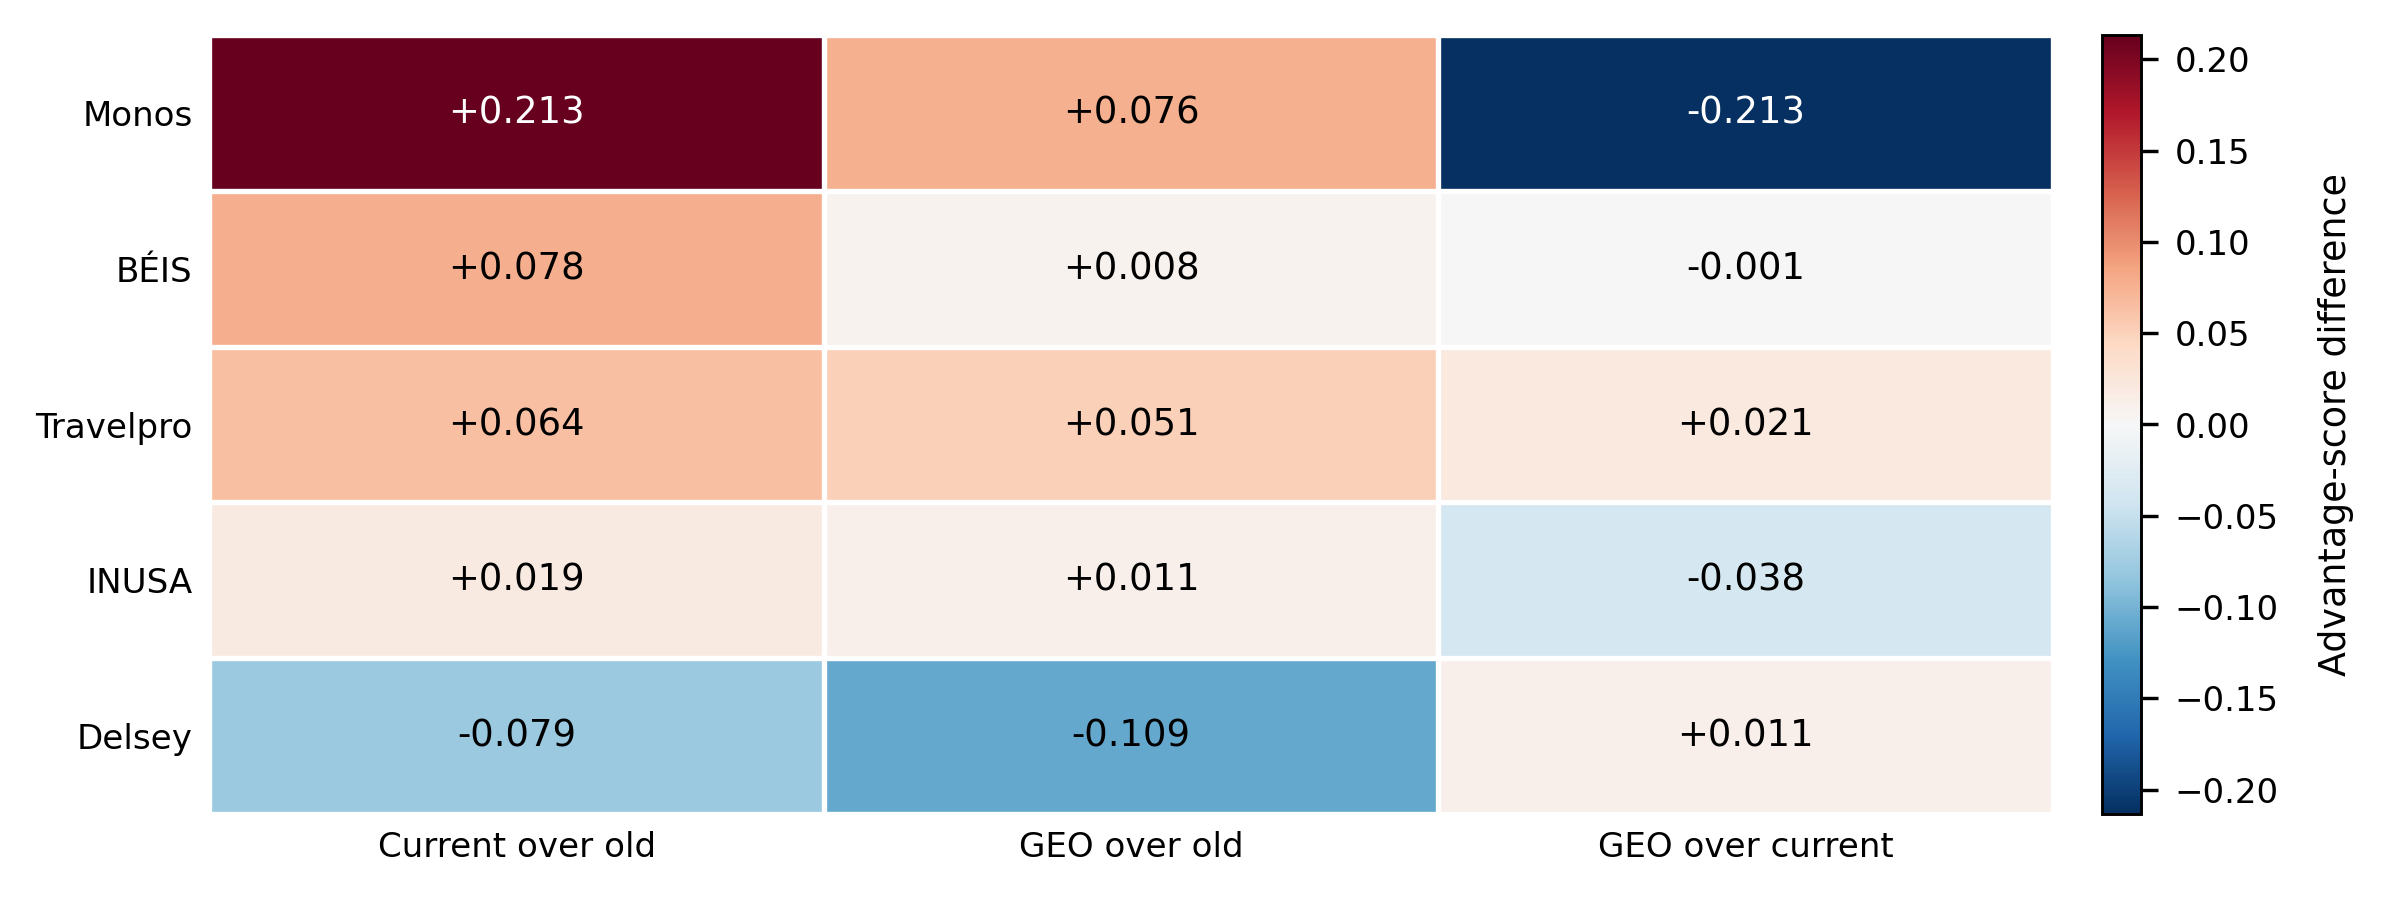

In [15]:
heatmap_cols = ["current_over_old", "geo_over_old", "geo_over_current"]
heatmap_labels = [
    "Current over old",
    "GEO over old",
    "GEO over current",
]
plot_df = summary.set_index("product").reindex(PRODUCT_ORDER)[heatmap_cols]
values = plot_df.to_numpy(dtype=float)

max_abs = np.nanmax(np.abs(values))
if not np.isfinite(max_abs) or max_abs == 0:
    max_abs = 0.1
vlim = max(0.05, max_abs)

fig, ax = plt.subplots(figsize=FIGSIZE_HEATMAP_FULL)
cmap = plt.get_cmap("RdBu_r")
norm = TwoSlopeNorm(vmin=-vlim, vcenter=0, vmax=vlim)
im = ax.imshow(values, cmap=cmap, norm=norm, aspect="auto")

ax.set_xticks(np.arange(len(heatmap_cols)))
ax.set_xticklabels(heatmap_labels)
ax.set_yticks(np.arange(len(PRODUCT_ORDER)))
ax.set_yticklabels(PRODUCT_ORDER)
ax.tick_params(axis="both", length=0)

ax.set_xticks(np.arange(-0.5, len(heatmap_cols), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(PRODUCT_ORDER), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.1)
ax.tick_params(which="minor", bottom=False, left=False)

for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        val = values[i, j]
        if np.isfinite(val):
            ax.text(j, i, f"{val:+.3f}", ha="center", va="center", fontsize=7.6, color=annotation_color(val, cmap, norm))

for spine in ax.spines.values():
    spine.set_visible(False)

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.025)
cbar.set_label("Advantage-score difference", labelpad=8)
cbar.outline.set_linewidth(0.6)

fig.tight_layout(pad=0.35)
save_pdf_png(fig, FIG_MAIN_DIR / "figure1_product_effect_heatmap")

## Main Figure 2 — Observed-vs-hypothetical GEO alignment scatter

Each point is one product. The x-axis is the one-product GEO-style rewrite effect relative to the all-old baseline. The y-axis is the one-product 2026 current-page effect relative to the same all-old baseline. This is the main alignment figure: it asks whether observed 2026 movement points in the same direction as the controlled GEO-style rewrite movement.


Saved: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\results\figures\main\figure2_observed_geo_alignment_scatter_single_column.pdf
Saved: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\results\figures\main\figure2_observed_geo_alignment_scatter_single_column.png


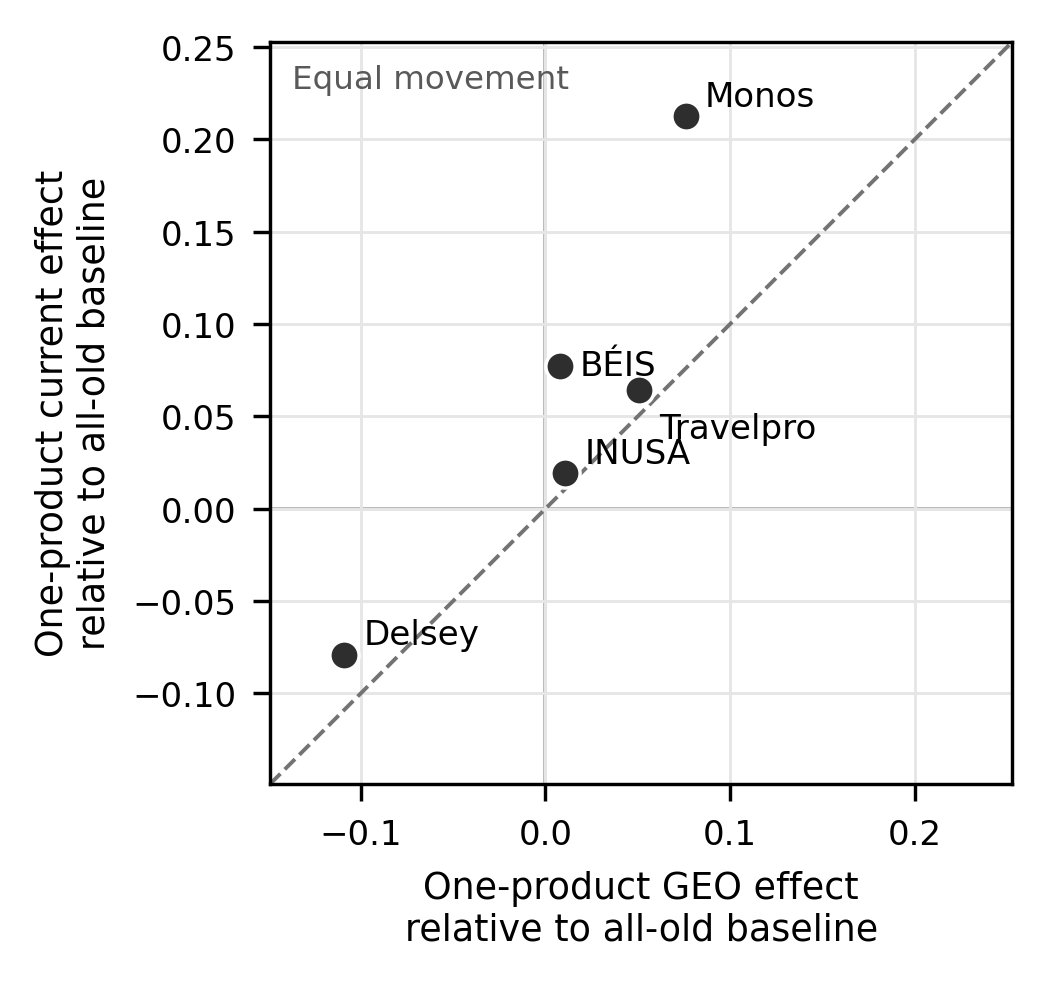

Saved: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\results\figures\main\figure2_observed_geo_alignment_scatter_full_width.pdf
Saved: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\results\figures\main\figure2_observed_geo_alignment_scatter_full_width.png


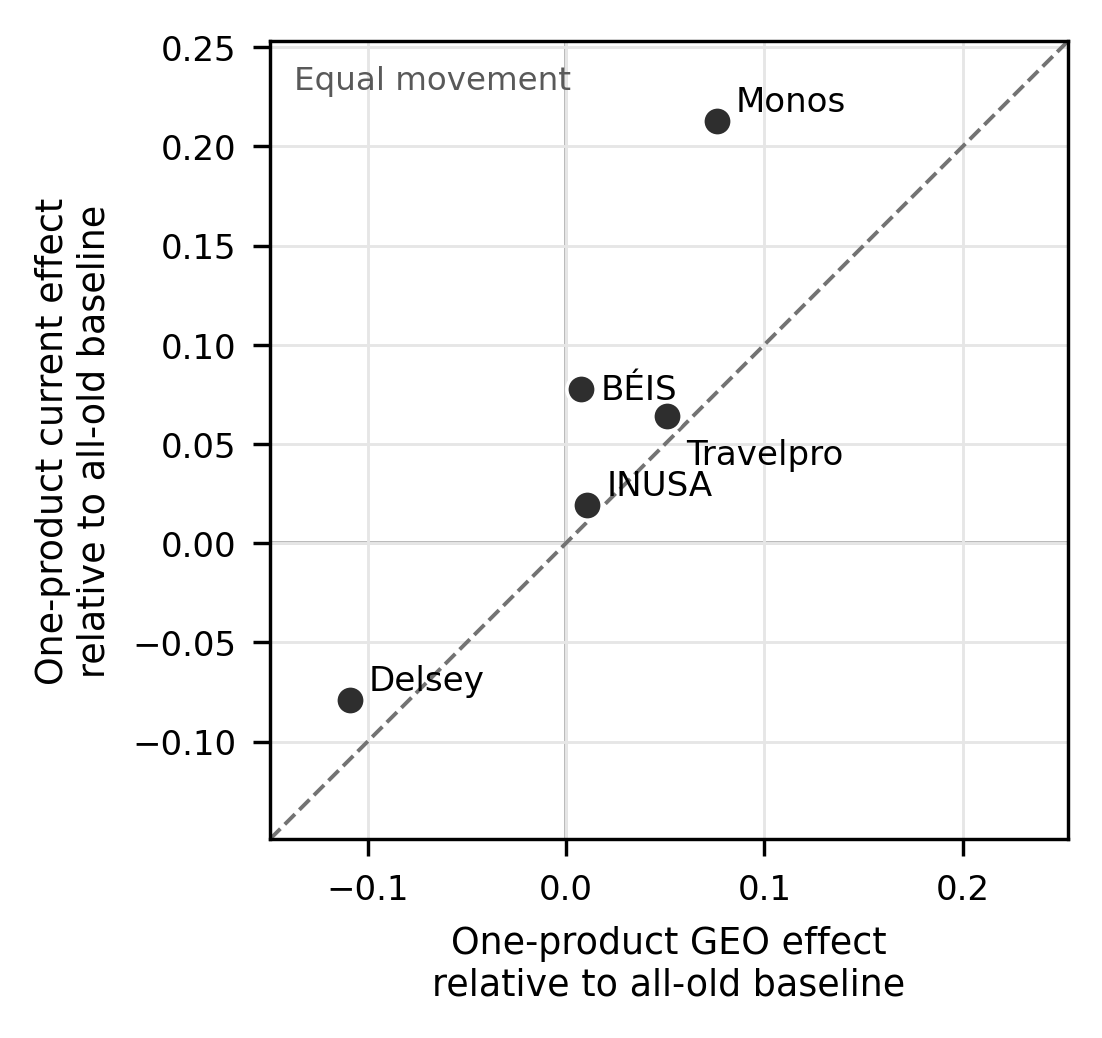

In [16]:
def make_alignment_scatter(figsize, out_name):
    df = summary.dropna(subset=["geo_over_old", "current_over_old"]).copy()
    x = df["geo_over_old"].to_numpy(float)
    y = df["current_over_old"].to_numpy(float)
    finite = np.concatenate([x[np.isfinite(x)], y[np.isfinite(y)]])
    lo = min(float(finite.min()) - 0.04, -0.02)
    hi = max(float(finite.max()) + 0.04, 0.02)

    fig, ax = plt.subplots(figsize=figsize)
    ax.axhline(0, color="0.72", linewidth=0.8, zorder=0)
    ax.axvline(0, color="0.72", linewidth=0.8, zorder=0)
    ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=0.8, color="0.45", zorder=1)
    ax.scatter(x, y, s=36, facecolor="0.18", edgecolor="white", linewidth=0.7, zorder=3)

    offsets = {"Monos": (4, 4), "BÉIS": (4, 0), "Travelpro": (4, -8), "INUSA": (4, 4), "Delsey": (4, 4)}
    for _, row in df.iterrows():
        dx, dy = offsets.get(row["product"], (4, 4))
        ax.annotate(row["product"], xy=(row["geo_over_old"], row["current_over_old"]),
                    xytext=(dx, dy), textcoords="offset points", fontsize=7.0, ha="left", va="center")

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("One-product GEO effect\nrelative to all-old baseline")
    ax.set_ylabel("One-product current effect\nrelative to all-old baseline")
    ax.text(0.03, 0.97, "Equal movement", transform=ax.transAxes, fontsize=6.7, ha="left", va="top", color="0.35")
    ax.grid(True, color="0.90", linewidth=0.6)
    ax.set_axisbelow(True)
    fig.tight_layout(pad=0.35)
    save_pdf_png(fig, FIG_MAIN_DIR / out_name)

make_alignment_scatter(FIGSIZE_SCATTER_SINGLE, "figure2_observed_geo_alignment_scatter_single_column")
make_alignment_scatter(FIGSIZE_SCATTER_FULL, "figure2_observed_geo_alignment_scatter_full_width")

## Supplementary Figure S1 — Metric-level one-product replacement effects

This decomposes the composite advantage score into metric components. It is intended as supplementary material. The colorbar is omitted because every cell is annotated numerically.


Saved: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\results\figures\supplementary\figureS1_metric_delta_heatmaps_no_colorbar.pdf
Saved: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\results\figures\supplementary\figureS1_metric_delta_heatmaps_no_colorbar.png


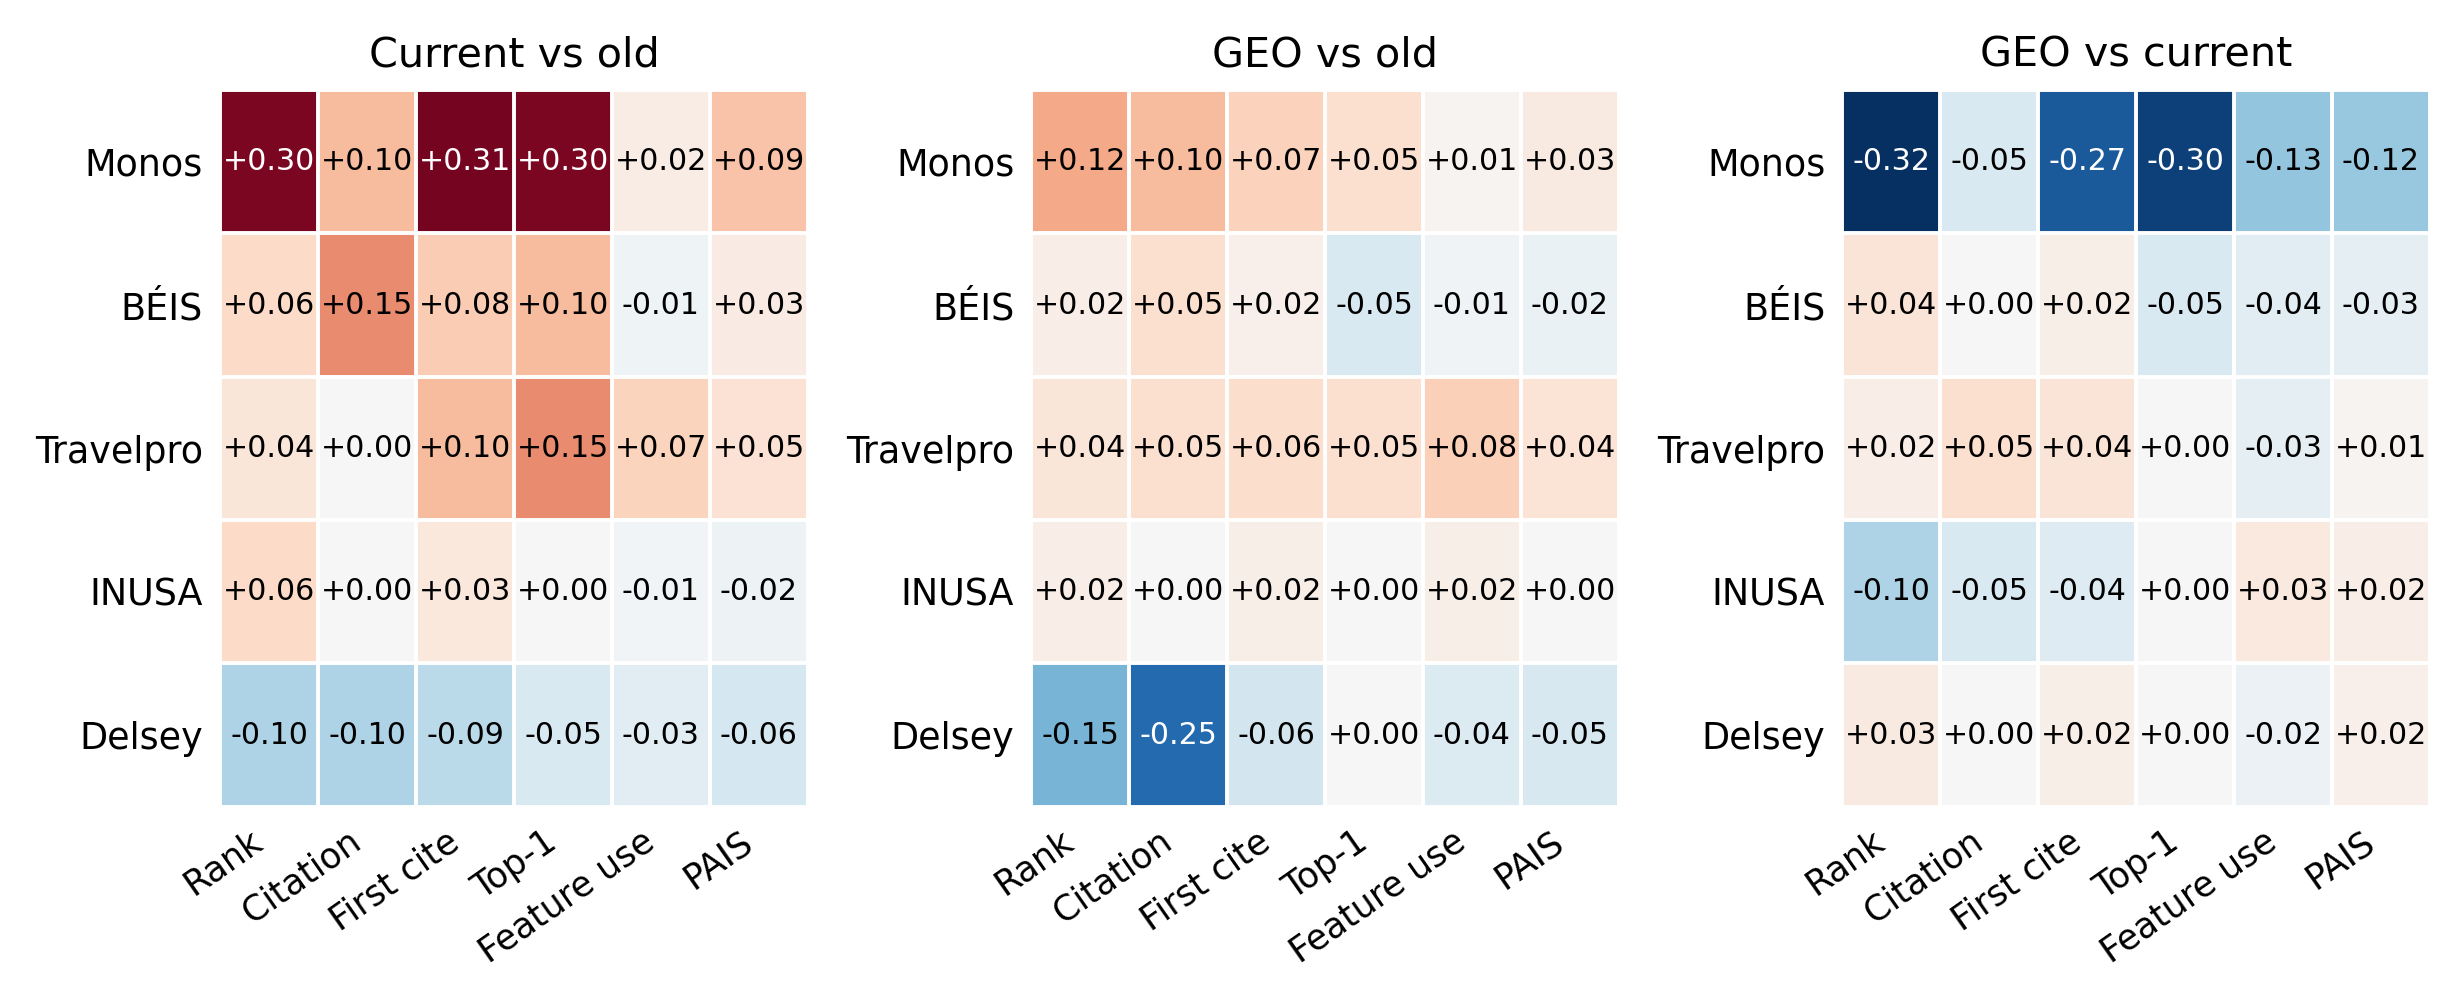

In [17]:
METRIC_CANDIDATES = [
    ("delta_rank_score_proxy", "Rank"),
    ("delta_citation_rate", "Citation"),
    ("delta_first_citation_score", "First cite"),
    ("delta_top1_cited_share", "Top-1"),
    ("delta_feature_coverage", "Feature use"),
    ("delta_PAIS", "PAIS"),
    ("delta_pais", "PAIS"),
]

def product_metric_matrix(df):
    pcol = infer_product_col(df)
    tmp = df.copy()
    tmp["product_norm"] = tmp[pcol].map(normalize_product)

    cols, labels = [], []
    lower = {c.lower(): c for c in tmp.columns}

    for wanted, label in METRIC_CANDIDATES:
        actual = wanted if wanted in tmp.columns else lower.get(wanted.lower())
        if actual is not None and actual not in cols and pd.api.types.is_numeric_dtype(tmp[actual]):
            cols.append(actual)
            labels.append(label)

    if not cols:
        return None, None

    mat = tmp.groupby("product_norm")[cols].mean().reindex(PRODUCT_ORDER)
    return mat, labels


items = []
for df, title in [
    (comp01, "Current vs old"),
    (comp02, "GEO vs old"),
    (comp03, "GEO vs current"),
]:
    mat, labels = product_metric_matrix(df)
    if mat is not None:
        items.append((mat, labels, title))


if len(items) == 0:
    print("No metric-level delta columns found; skipping Figure S1.")

else:
    vals = np.concatenate([m.to_numpy(float).ravel() for m, _, _ in items])
    vals = vals[np.isfinite(vals)]

    vlim = max(0.05, float(np.max(np.abs(vals))) if vals.size else 0.1)

    cmap = plt.get_cmap("RdBu_r")
    norm = TwoSlopeNorm(vmin=-vlim, vcenter=0, vmax=vlim)

    # Full-width supplementary figure, without colorbar.
    fig, axes = plt.subplots(
        1,
        len(items),
        figsize=(6.9, 3.25),
        squeeze=False,
        constrained_layout=False,
    )

    axes = axes.ravel()

    for ax, (mat, labels, title) in zip(axes, items):
        arr = mat.to_numpy(float)

        ax.imshow(arr, cmap=cmap, norm=norm, aspect="auto")

        ax.set_title(title, fontsize=8.5, pad=5)

        ax.set_xticks(np.arange(len(labels)))
        ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=7.2)

        ax.set_yticks(np.arange(len(PRODUCT_ORDER)))
        ax.set_yticklabels(PRODUCT_ORDER, fontsize=7.5)

        ax.tick_params(axis="both", length=0)

        ax.set_xticks(np.arange(-0.5, len(labels), 1), minor=True)
        ax.set_yticks(np.arange(-0.5, len(PRODUCT_ORDER), 1), minor=True)
        ax.grid(which="minor", color="white", linewidth=0.8)
        ax.tick_params(which="minor", bottom=False, left=False)

        for i in range(arr.shape[0]):
            for j in range(arr.shape[1]):
                val = arr[i, j]
                if np.isfinite(val):
                    txt_color = annotation_color(val, cmap, norm)
                    ax.text(
                        j,
                        i,
                        f"{val:+.2f}",
                        ha="center",
                        va="center",
                        fontsize=6.2,
                        color=txt_color,
                    )

        for spine in ax.spines.values():
            spine.set_visible(False)

    # Manual spacing so panels do not overlap.
    fig.subplots_adjust(
        left=0.08,
        right=0.995,
        top=0.88,
        bottom=0.25,
        wspace=0.38,
    )

    save_pdf_png(fig, FIG_SUPP_DIR / "figureS1_metric_delta_heatmaps_no_colorbar")

## Supplementary Figure S2 — Direct GEO-vs-current contrast

This isolates Comparison 03. Positive values mean the one-product GEO-style rewrite produced stronger answer behavior than the corresponding 2026 current page under the all-current baseline setup. Negative values mean the 2026 current page was stronger than the GEO-style rewrite.


Saved: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\results\figures\supplementary\figureS2_geo_vs_current_bar.pdf
Saved: C:\Users\junse\Documents\research\Finance Research\GEO_carry-on\results\figures\supplementary\figureS2_geo_vs_current_bar.png


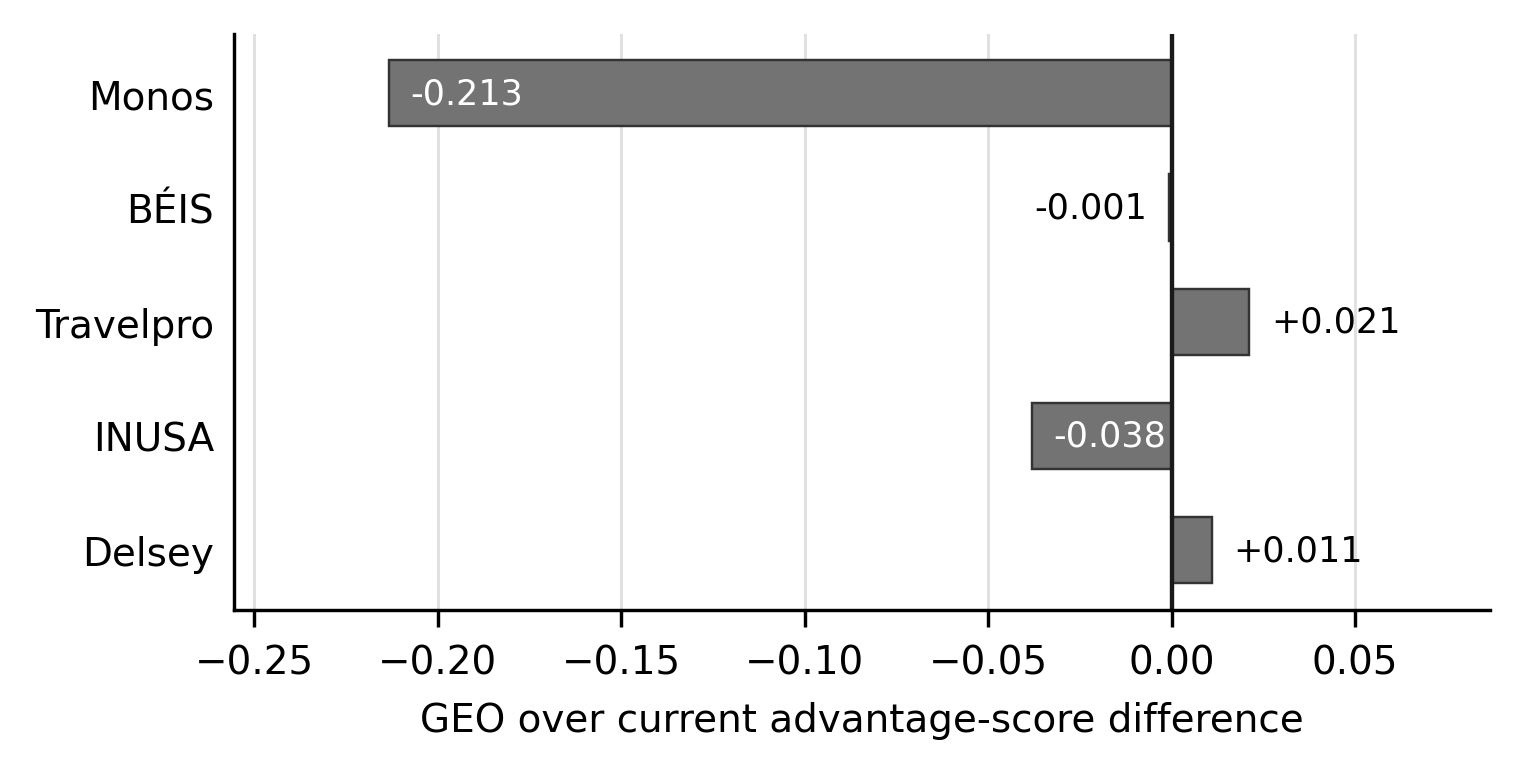

In [18]:
bar_df = summary.dropna(subset=["geo_over_current"]).copy()
bar_df["order"] = bar_df["product"].map({p: i for i, p in enumerate(PRODUCT_ORDER)}).fillna(999)
bar_df = bar_df.sort_values("order")

vals = bar_df["geo_over_current"].to_numpy(float)
products = bar_df["product"].tolist()
ypos = np.arange(len(bar_df))

fig, ax = plt.subplots(figsize=mm_to_inch(120, 58))

# Publication-style neutral bars
bars = ax.barh(
    ypos,
    vals,
    color="0.45",
    edgecolor="0.20",
    linewidth=0.5,
    height=0.58,
)

# Zero reference line
ax.axvline(0, color="0.10", linewidth=0.9)

# Y axis
ax.set_yticks(ypos)
ax.set_yticklabels(products, fontsize=8)
ax.invert_yaxis()

# X axis
ax.set_xlabel("GEO over current advantage-score difference", fontsize=8)
ax.tick_params(axis="x", labelsize=8)
ax.tick_params(axis="y", length=0, pad=4)

# Symmetric-ish x limits with enough room for text labels
xmin = min(np.nanmin(vals), 0)
xmax = max(np.nanmax(vals), 0)
span = max(xmax - xmin, 0.08)

ax.set_xlim(xmin - 0.18 * span, xmax + 0.28 * span)

# Light grid only on x axis
ax.grid(axis="x", color="0.88", linewidth=0.6)
ax.set_axisbelow(True)

# Numeric labels: large bars inside, small bars outside
offset = 0.025 * span
inside_threshold = 0.12 * span

for y, val in zip(ypos, vals):
    label = f"{val:+.3f}"

    if abs(val) >= inside_threshold:
        # Put label inside the bar to avoid overlapping y-axis labels
        if val < 0:
            x_text = val + offset
            ha = "left"
        else:
            x_text = val - offset
            ha = "right"
        color = "white"
    else:
        # Put small values just outside the bar
        if val < 0:
            x_text = val - offset
            ha = "right"
        else:
            x_text = val + offset
            ha = "left"
        color = "black"

    ax.text(
        x_text,
        y,
        label,
        va="center",
        ha=ha,
        fontsize=7.2,
        color=color,
        clip_on=False,
    )

# Clean frame
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_linewidth(0.7)
ax.spines["bottom"].set_linewidth(0.7)

# More left margin so product names never collide
fig.subplots_adjust(
    left=0.20,
    right=0.96,
    top=0.96,
    bottom=0.24,
)

save_pdf_png(fig, FIG_SUPP_DIR / "figureS2_geo_vs_current_bar")